In [1]:
using Pkg
Pkg.activate("/home/camilla/u1symmetry") #this needs to be changed if ran in another device
Pkg.status()

  Activating project at `~/u1symmetry`


Status `~/u1symmetry/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [13f3f980] CairoMakie v0.15.10
  [7a1cc6ca] FFTW v1.10.0
  [7073ff75] IJulia v1.34.4
  [1dea7af3] OrdinaryDiffEq v7.0.0
  [6c2fb7c5] QuantumToolbox v0.47.0
  [295af30f] Revise v3.14.3
  [90137ffa] StaticArrays v1.9.18
  [789caeaf] StochasticDiffEq v7.0.0
  [2f01184e] SparseArrays v1.12.0


In [2]:
using QuantumToolbox
using CairoMakie
using LinearAlgebra
include("superenrspace.jl")
using .SuperEnrSpace


# One site case
The Hamiltonian reads:
$$\hat{H} = \omega_0 \hat{a}^\dagger\hat{a} + \frac{U}{2}\hat{a}^{\dagger 2}\hat{a}^2$$
with $\mathcal{D}[\hat{a}]$ and $\mathcal{D}[\hat{a^2}]$ 

As a reminder, the vectorized representation of Lindblad equation is the following: 
$$\mathcal{L}\ket{\rho} = -i(H-\tilde{H})\ket{\rho} + \sum_i \gamma_i (\sigma_{L_i}L_i\tilde{L}_i - \frac{1}{2}L_i^\dagger L_i - \frac{1}{2}\tilde{L}_i^\dagger \tilde{L}_i)\ket{\rho}$$

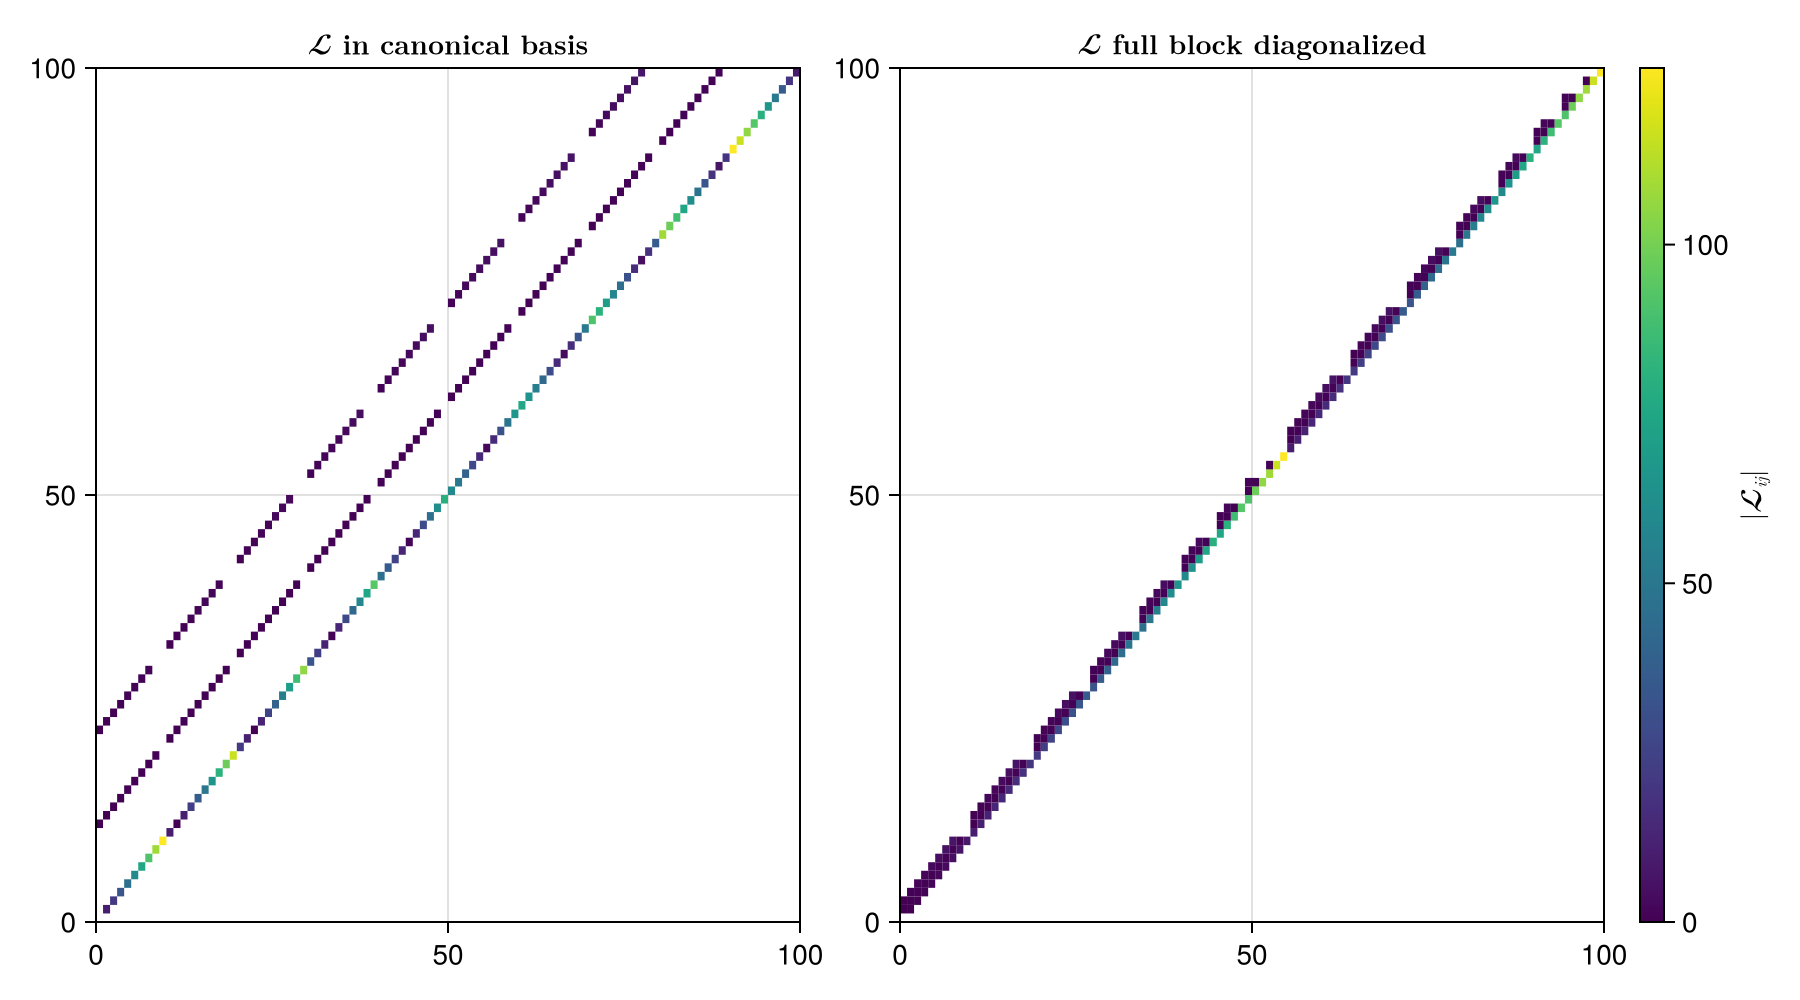

19


In [11]:
cutoff = 10 
a = destroy(cutoff)
ω = 10.
U = 1.
γ = 0.1
H = ω * a' * a + U/2 * a'^2 * a^2
L = liouvillian(H, [sqrt(γ)*a, sqrt(γ)*(a^2)]);
L_diag = block_diagonal_form(L)

fig = Figure(size = (900,500))
cmax = maximum(abs.(L.data))
ax1 = Axis(fig[1,1], title = L"\mathcal{L}\textbf{ in canonical basis}")
ax2 = Axis(fig[1,2], title=L"\mathcal{L}\textbf{ full block diagonalized}")
p1 = spy!(ax1, abs.(L.data), colorrange = (0, cmax))
p2 = spy!(ax2, abs.(L_diag.B.data), colorrange = (0, cmax))
Colorbar(fig[1,3], p1, label = L"|\mathcal{L}_{ij}|")
display(fig)
println(length(L_diag.blocks))




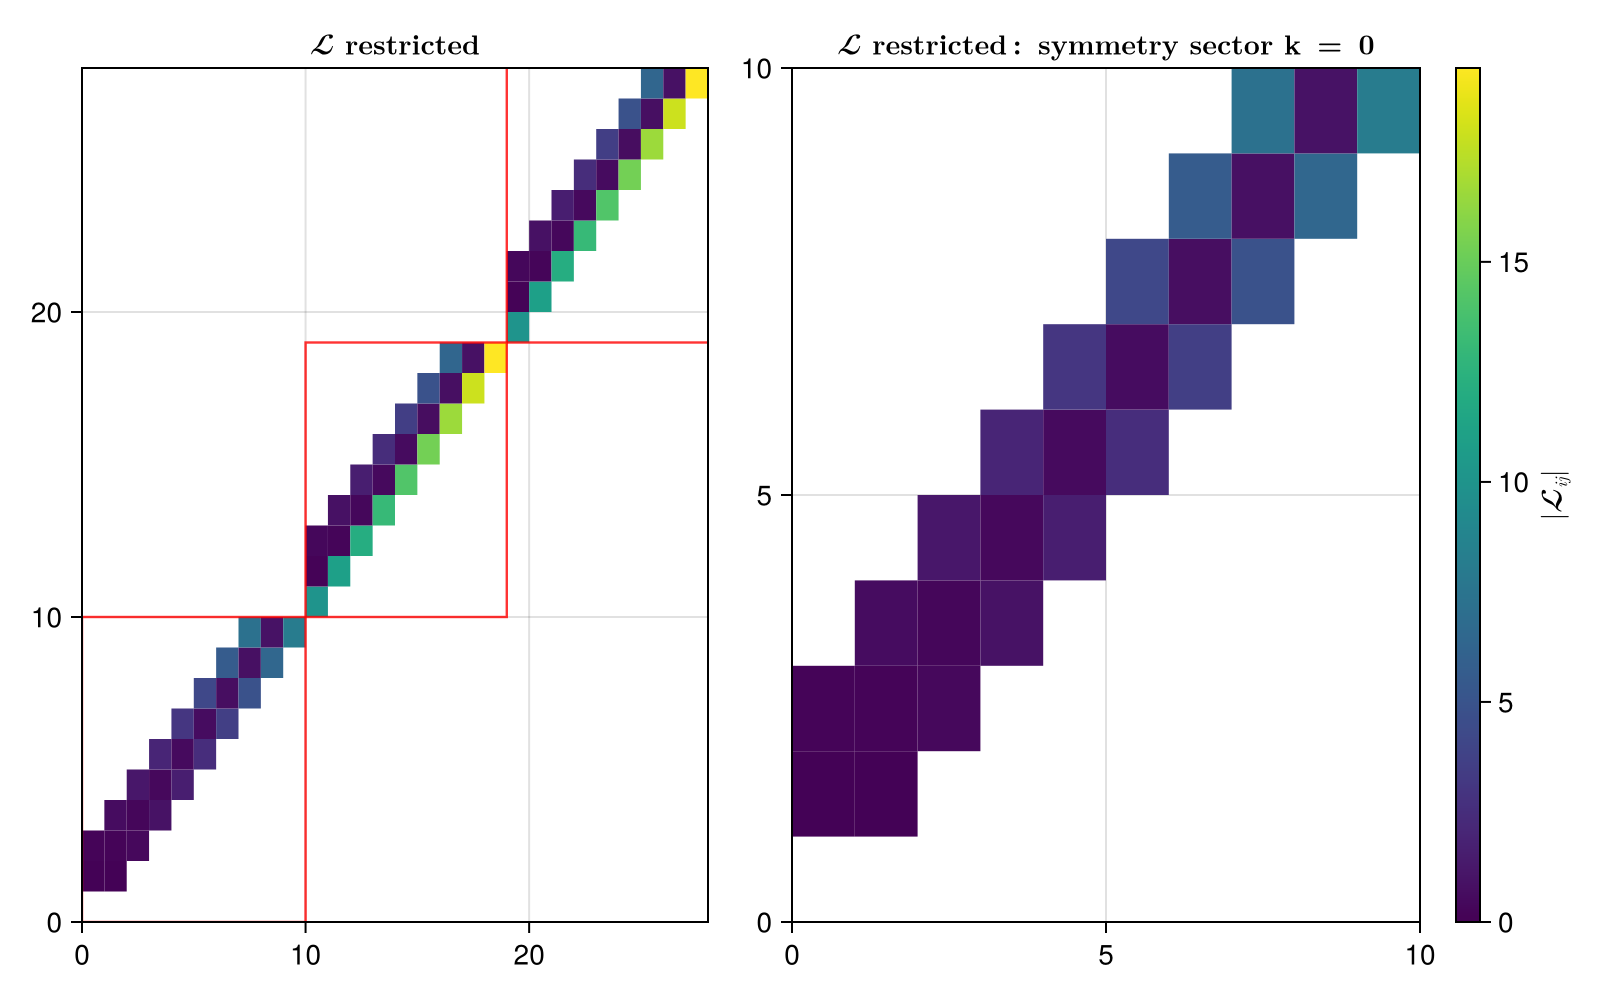

0.0


CairoMakie.Screen{PDF}


In [22]:
"""
restricted space case
"""
space = s_enr_space((10,),1,2) #p = 2 is necessary to correctly construct destroy operators
vec_id = s_enr_identity(space) 
a_left, a_right = s_enr_destroy(space, 1)
H_left = ω * a_left' * a_left + (U/2) * a_left'^2 * a_left^2
H_right = ω * a_right' * a_right + (U/2) * a_right'^2 * a_right^2
c_ops = [(sqrt(γ)*a_left, sqrt(γ)*a_right), (sqrt(γ)*a_left^2, sqrt(γ)*a_right^2)]
L_restricted = s_enr_liouvillian(space, H_left, H_right, c_ops)

#identity check <I|L = 0
result = (vec_id' * L_restricted).data
println(maximum(abs, result))
#plotting
cmax = maximum(abs.(L_restricted.data))

fig = Figure(size = (800,500))
ax = Axis(fig[1,1], title = L"\mathcal{L}\textbf{ restricted}")
ax2 = Axis(fig[1,2], title = L"\mathcal{L}\textbf{ restricted: symmetry sector k = 0}")
p1 = spy!(ax, abs.(L_restricted.data), colorrange = (0, cmax))
p2 = spy!(ax2, abs.(L_restricted.data[space.blocks[0], space.blocks[0]]), colorrange = (0, cmax))
n = size(L_restricted.data, 1)
for (k, r) in space.blocks
    last(r) > n && continue          # skip extended-only blocks
    i0, i1 = first(r) -1. , last(r) 
    lines!(ax, [i0, i1, i1, i0, i0], [i0, i0, i1, i1, i0],
           color = (:red, 0.8), linewidth = 1.2)
end
Colorbar(fig[1,3],p1,label = L"|\mathcal{L}_{ij}|")
display(fig)
save("l1site.pdf", fig)

In [7]:
"""
Eigenvalues check: the restricted eigenvalues should be a subset of the full ones, 
specifically the ones corresponding to the blocks with |q| ≤ n_exc (in this case n_exc = 1)
"""
evals_full = eigvals(Matrix(L.data))
evals_restricted = eigvals(Matrix(L_restricted.data))

function approx_in(val, collection; tol=1e-10)
    return any(abs(val - x) < tol for x in collection)
end

matches = [approx_in(e, evals_full) for e in evals_restricted]
println("Matched: $(sum(matches)) / $(length(evals_restricted))")
println("Unmatched eigenvalues:")
for (e, m) in zip(evals_restricted, matches)
    if !m
        println("  $e")
    end
end


Matched: 28 / 28
Unmatched eigenvalues:


In [8]:
# if there are some unmatched eigenvalues, find which eigenstates correspond to the unmatched values
# it was used for debugging, not needed anymore
evals_r, evecs_r = eigen(Matrix(L_restricted.data))

unmatched_indices = findall(i -> !approx_in(evals_r[i], evals_full), 1:length(evals_r))

println("Unmatched eigenstates:")
for idx in unmatched_indices
    eval = evals_r[idx]
    evec = evecs_r[:, idx]
    
    # find dominant components
    dominant = sortperm(abs.(evec), rev=true)[1:3]
    
    println("\nEigenvalue: $eval")
    for d in dominant
        ket, bra = space.idx2state[d]
        q = sum(ket) - sum(bra)
        println("  amplitude $(round(abs(evec[d]), digits=4)) on state (ket=$ket, bra=$bra, q=$q)")
    end
end

Unmatched eigenstates:


# Two site case

In this case the Hamiltonian is:
$$\hat{H} = \omega_a \hat{a}^\dagger \hat{a} + \omega_b \hat{b}^\dagger \hat{b} + \frac{U}{2}\hat{a}^{\dagger}\hat{a}^2 + \frac{U}{2}\hat{a}^{\dagger}\hat{a}^2$$
and the dissipators are $\mathcal{D}[\hat{a}]$, $\mathcal{D}[\hat{b}]$, $\mathcal{D}[\hat{a}^2]$, $\mathcal{D}[\hat{b}^2]$


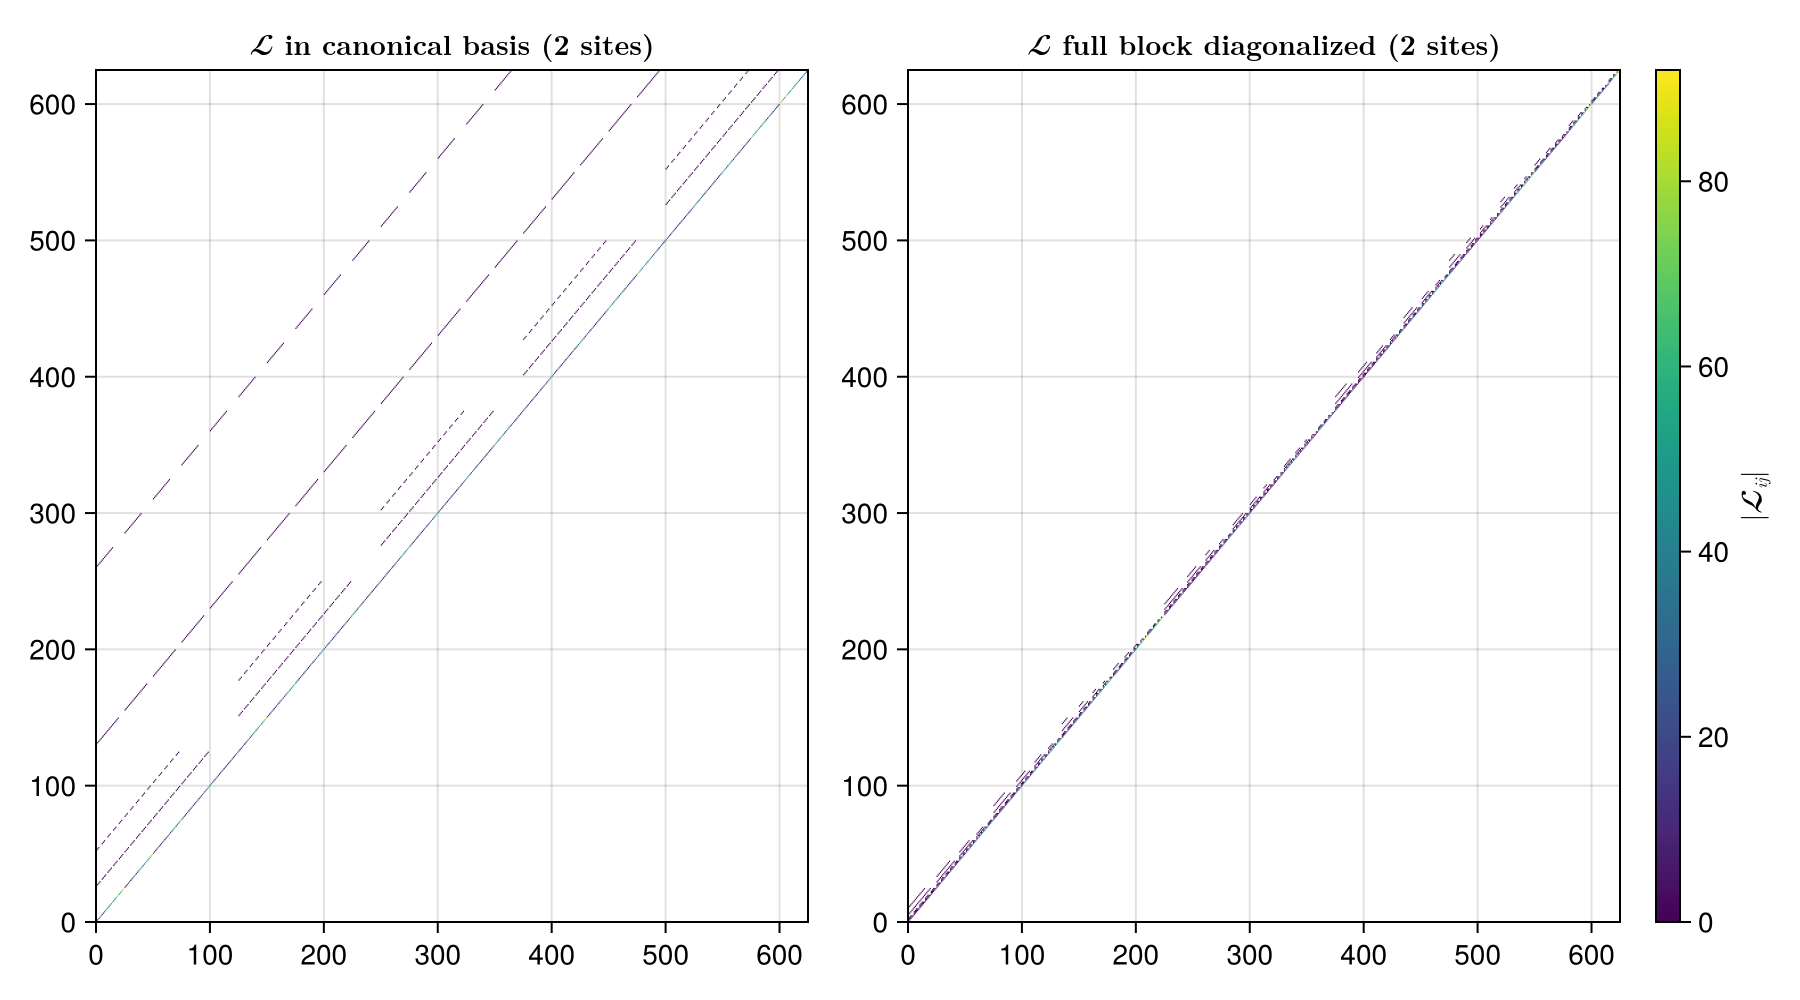

81


In [24]:
#full space case
cutoff = 5
a = destroy(cutoff) ⊗ qeye(cutoff)
b = qeye(cutoff) ⊗ destroy(cutoff)
ωa = 10.
ωb = 10.
U = 1.
γa = 0.1
γb = 0.1
H = ωa * a' * a + ωb * b' * b + U/2 * a'^2 * a^2 + U/2 * b'^2 * b^2
L2 = liouvillian(H, [sqrt(γa)*a, sqrt(γb)*b, sqrt(γa)*(a^2), sqrt(γb)*(b^2)]);
L2_diag = block_diagonal_form(L2)

fig = Figure(size = (900,500))
cmax = maximum(abs.(L2.data))
ax1 = Axis(fig[1,1], title = L"\mathcal{L}\textbf{ in canonical basis (2 sites)}")
ax2 = Axis(fig[1,2], title= L"\mathcal{L}\textbf{ full block diagonalized (2 sites)}")
p1 = spy!(ax1, abs.(L2.data), colorrange = (0, cmax))
p2 = spy!(ax2, abs.(L2_diag.B.data), colorrange = (0, cmax))
Colorbar(fig[1,3], p1, label = L"|\mathcal{L}_{ij}|")
display(fig)
println(length(L2_diag.blocks))

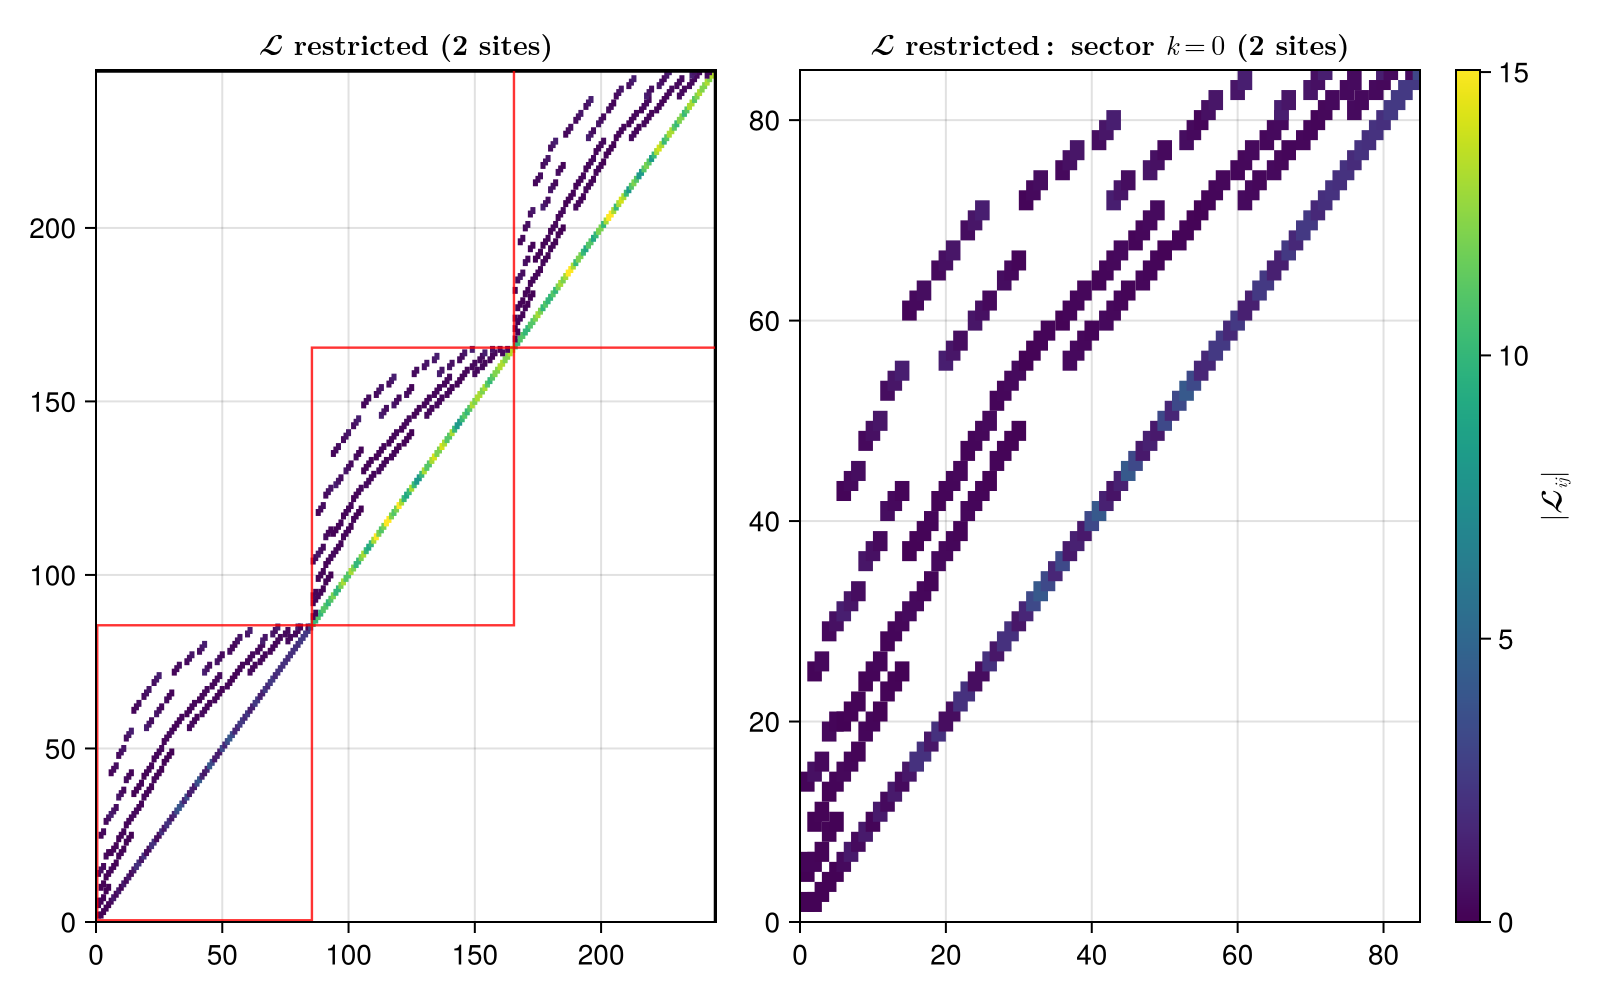

4.440892098500626e-16
ComplexF64[]


CairoMakie.Screen{PDF}


In [25]:
# now restricted space
space = s_enr_space((cutoff,cutoff),1,2) 
vec_id = s_enr_identity(space)
a_left, a_right = s_enr_destroy(space, 1)
b_left, b_right = s_enr_destroy(space, 2)
H_left = ωa * a_left' * a_left + ωb * b_left' * b_left + (U/2) * a_left'^2 * a_left^2 + U/2 * b_left'^2 * b_left^2
H_right = ωa * a_right' * a_right + ωb * b_right' * b_right + (U/2) * a_right'^2 * a_right^2 + U/2 * b_right'^2 * b_right^2
c_ops = [(sqrt(γa)*a_left, sqrt(γa)*a_right), (sqrt(γb)*b_left, sqrt(γb)*b_right), (sqrt(γa)*a_left^2, sqrt(γa)*a_right^2), (sqrt(γb)*b_left^2, sqrt(γb)*b_right^2)]
L2_restricted = s_enr_liouvillian(space, H_left, H_right, c_ops)

#identity check <I|L = 0
result = (vec_id' * L2_restricted).data
nonzero_values = filter(x -> abs(x) > 1e-9, result)
println(maximum(abs, result))
println(nonzero_values)
#plotting

fig = Figure(size = (800,500))
cmax = maximum(abs.(L2_restricted.data))
ax  = Axis(fig[1,1], title = L"\mathcal{L}\textbf{ restricted (2 sites)}")
ax2 = Axis(fig[1,2], title = L"\mathcal{L}\textbf{ restricted: sector } k=0 \textbf{ (2 sites)}")

p1 = spy!(ax,  abs.(L2_restricted.data), colorrange = (0, cmax), markersize = 2)
p2 = spy!(ax2, abs.(L2_restricted.data[space.blocks[0], space.blocks[0]]),
          colorrange = (0, cmax), markersize = 2)

# outline each symmetry sector on the full matrix
n = size(L2_restricted.data, 1)
for (k, r) in space.blocks
    last(r) > n && continue          # skip extended-only blocks
    i0, i1 = first(r) - 0.5, last(r) + 0.5
    lines!(ax, [i0, i1, i1, i0, i0], [i0, i0, i1, i1, i0],
           color = (:red, 0.8), linewidth = 1.2)
end

Colorbar(fig[1,3], p1, label = L"|\mathcal{L}_{ij}|")
display(fig)
save("l2site.pdf", fig)

## Eigenvalues check

In [16]:
evals_full2 = eigvals(Matrix(L2.data))
evals_restricted2 = eigvals(Matrix(L2_restricted.data))

matches2 = [approx_in(e, evals_full2) for e in evals_restricted2]
println("Matched: $(sum(matches2)) / $(length(evals_restricted2))")
println("Unmatched eigenvalues:")
for (e, m) in zip(evals_restricted2, matches2)
    if !m
        println("  $e")
    end
end

Matched: 245 / 245
Unmatched eigenvalues:


# Dynamics
To do some dynamics on the single state, two initial states are chosen: 

$\rho_0 = \ket{3}\bra{3}$ and $\rho_0 = \ket{\psi_+}\bra{\psi_+}$ with $\ket{\psi_+} = \frac{1}{\sqrt{2}}(\ket{2}+\ket{3})$.

This second initial state involves blocks with n_exc = 0, +1, -1, while the first only the 0-th block. 

After building the initial state, I evolved it under the Liouvillian and expectation values of observables are computed at each time. Finally, the evolution is compared with the full space case. 
## Checks that are done in the code below: 
- exponential decay towards zero (no pumping)
- Verification that the trace is preserved at all time, so $\braket{I|\rho_t} = 1$
- comparison with full space case

In [26]:
#full space first to understand the physics
# rewriting parameters and H for clarity
cutoff = 10
ω = 10.0
U = 1.0
γ = 0.1

a = destroy(cutoff)
H = ω * a' * a + (U/2) * a'^2 * a^2
c_ops = [sqrt(γ) * a, sqrt(γ) * a^2]

# observables
N    = a' * a            # number
N2   = a'^2 * a^2        # pairs

ρ0 = fock_dm(cutoff, 3)

ψ_plus = (fock(cutoff, 2) + fock(cutoff, 3)) / sqrt(2)
ρ0_m = ψ_plus * ψ_plus'

# time evolution
tlist = 0:0.05:5

# evolve both states
sol1 = mesolve(H, ρ0, tlist, c_ops, e_ops=[N, N2, a, a'])
sol2 = mesolve(H, ρ0_m, tlist, c_ops, e_ops=[N, N2, a, a'])

# extract expectation values
N_t_s1    = real.(sol1.expect[1, :])
N2_t_s1   = real.(sol1.expect[2, :])
A_t_s1    = sol1.expect[3, :]              # complex — keep both parts
Adag_t_s1 = sol1.expect[4, :]

N_t_s2    = real.(sol2.expect[1, :])
N2_t_s2   = real.(sol2.expect[2, :])
A_t_s2    = sol2.expect[3, :]
Adag_t_s2 = sol2.expect[4, :];

[mesolve] 100%|███████████████████████████| Time: 0:00:00 ( 6.24 μs/it)
[mesolve] 100%|███████████████████████████| Time: 0:00:00 (14.66 μs/it)


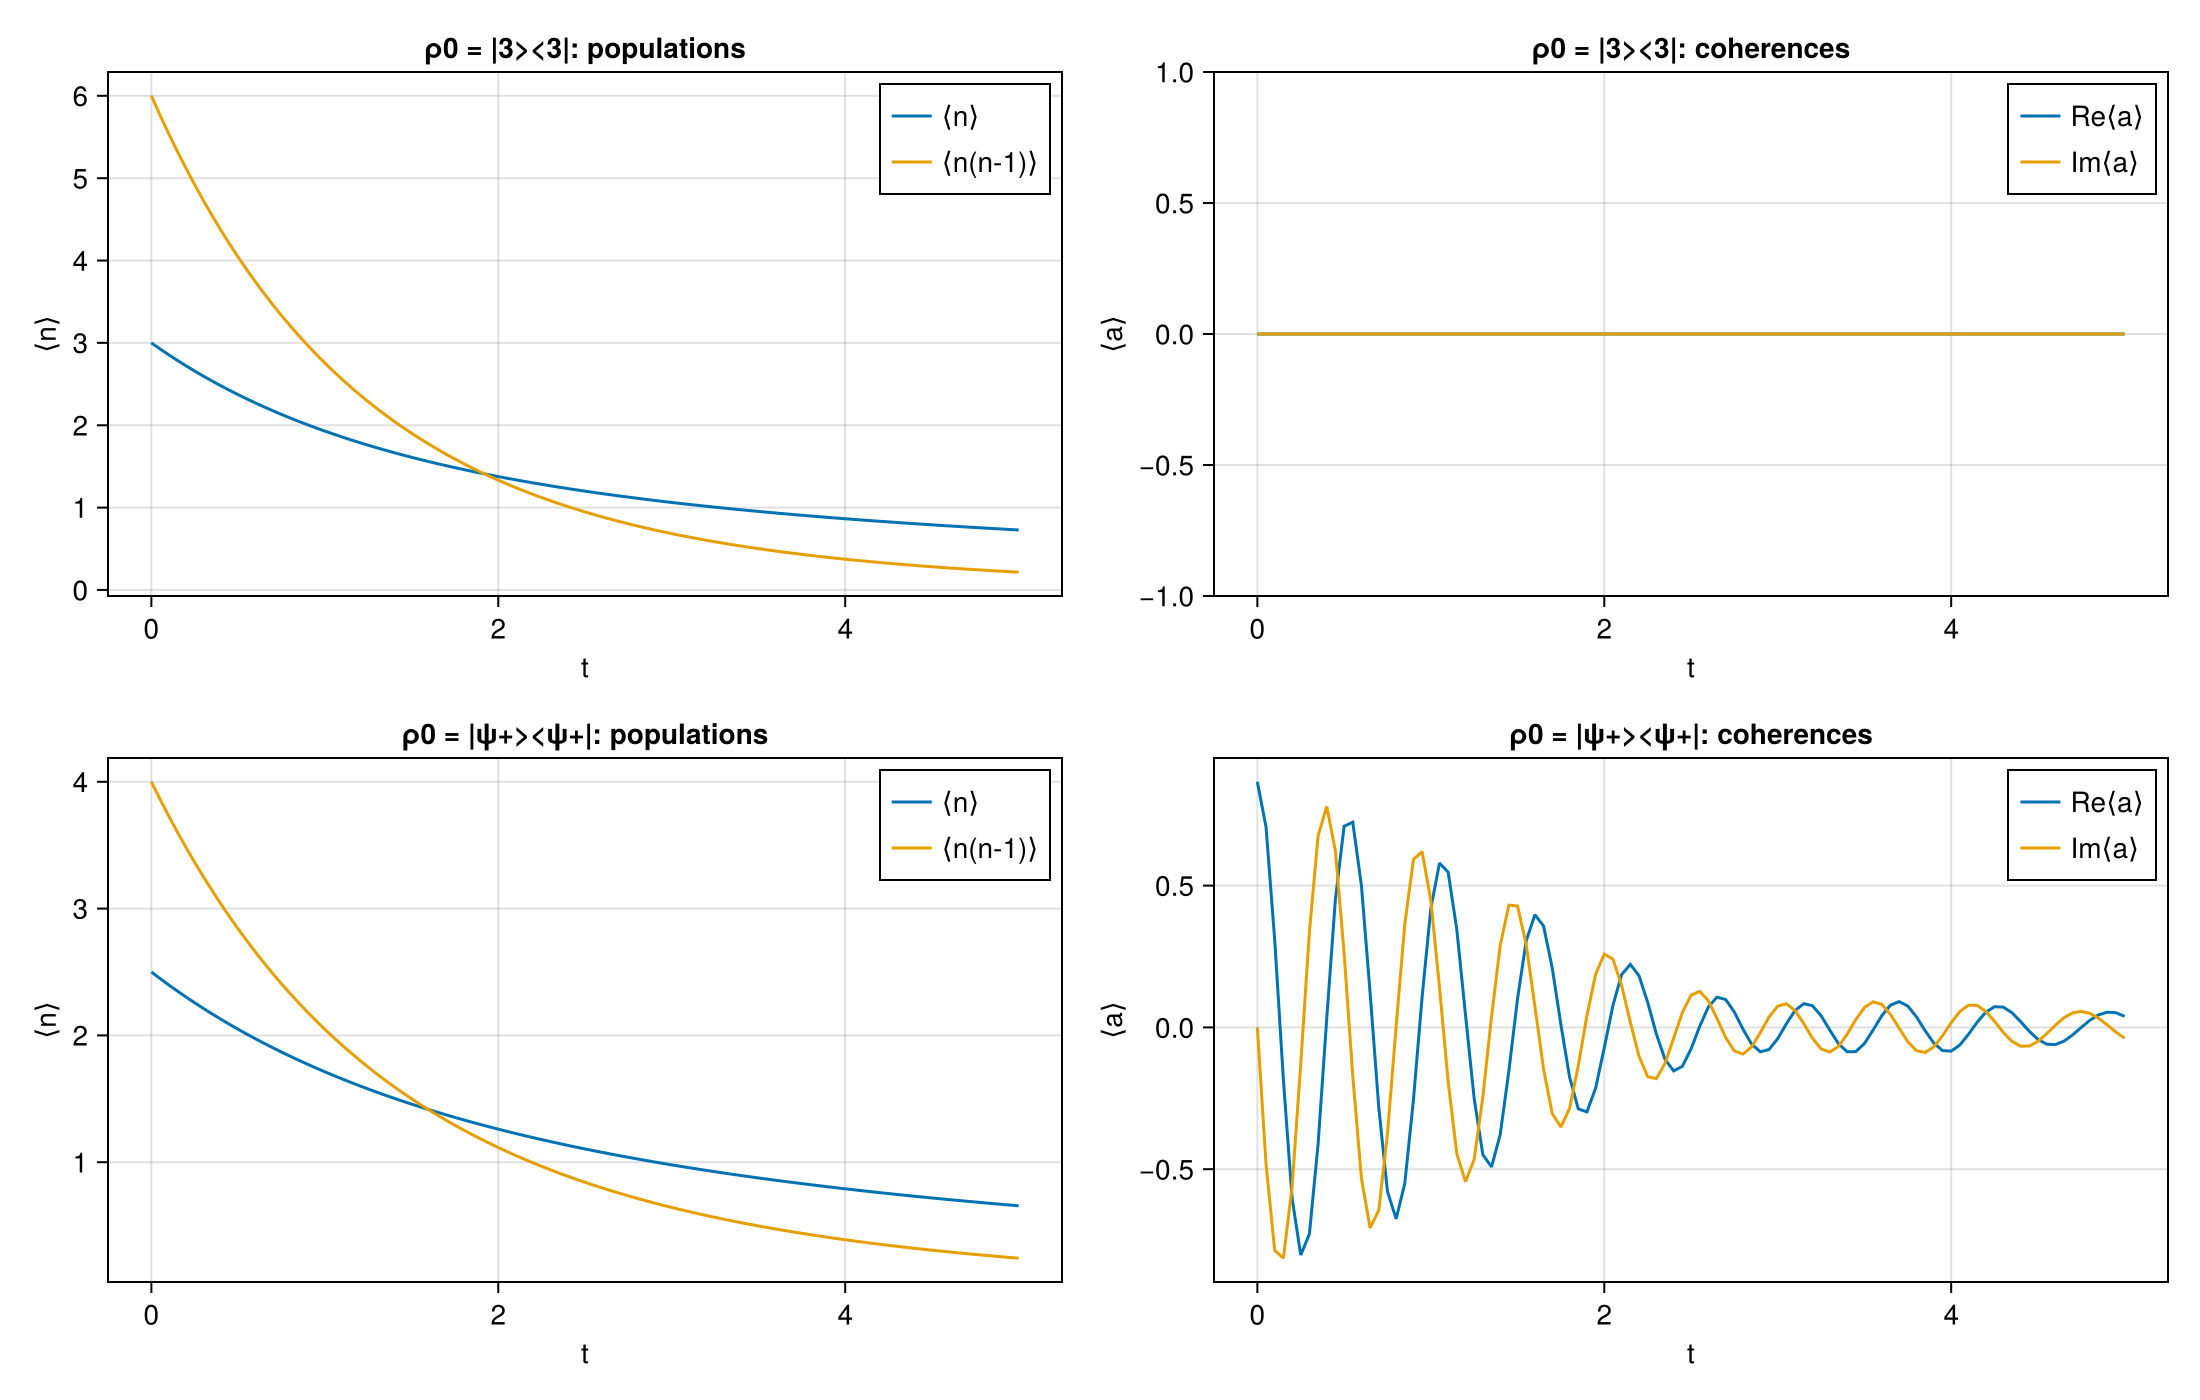

CairoMakie.Screen{IMAGE}


In [27]:
#plotting
fig = Figure(size = (1100, 700))

# State 1
ax1 = Axis(fig[1,1], title="ρ0 = |3><3|: populations", xlabel="t", ylabel="⟨n⟩")
lines!(ax1, tlist, N_t_s1, label="⟨n⟩")
lines!(ax1, tlist, N2_t_s1, label="⟨n(n-1)⟩")
axislegend(ax1)

ax2 = Axis(fig[1,2], title="ρ0 = |3><3|: coherences", xlabel="t", ylabel="⟨a⟩")
lines!(ax2, tlist, real.(A_t_s1), label="Re⟨a⟩")
lines!(ax2, tlist, imag.(A_t_s1), label="Im⟨a⟩")
axislegend(ax2)
# expectation: ⟨a⟩ ≡ 0 for state 1 (no coherences)

# State 2
ax3 = Axis(fig[2,1], title="ρ0 = |ψ+><ψ+|: populations", xlabel="t", ylabel="⟨n⟩")
lines!(ax3, tlist, N_t_s2, label="⟨n⟩")
lines!(ax3, tlist, N2_t_s2, label="⟨n(n-1)⟩")
axislegend(ax3)

ax4 = Axis(fig[2,2], title="ρ0 = |ψ+><ψ+|: coherences", xlabel="t", ylabel="⟨a⟩")
lines!(ax4, tlist, real.(A_t_s2), label="Re⟨a⟩")
lines!(ax4, tlist, imag.(A_t_s2), label="Im⟨a⟩")
axislegend(ax4)
# expectation: ⟨a⟩ oscillates with frequency ω and decays

display(fig)

Trace preservation check (<I|ρ(t)> - 1 = 0): ComplexF64[]


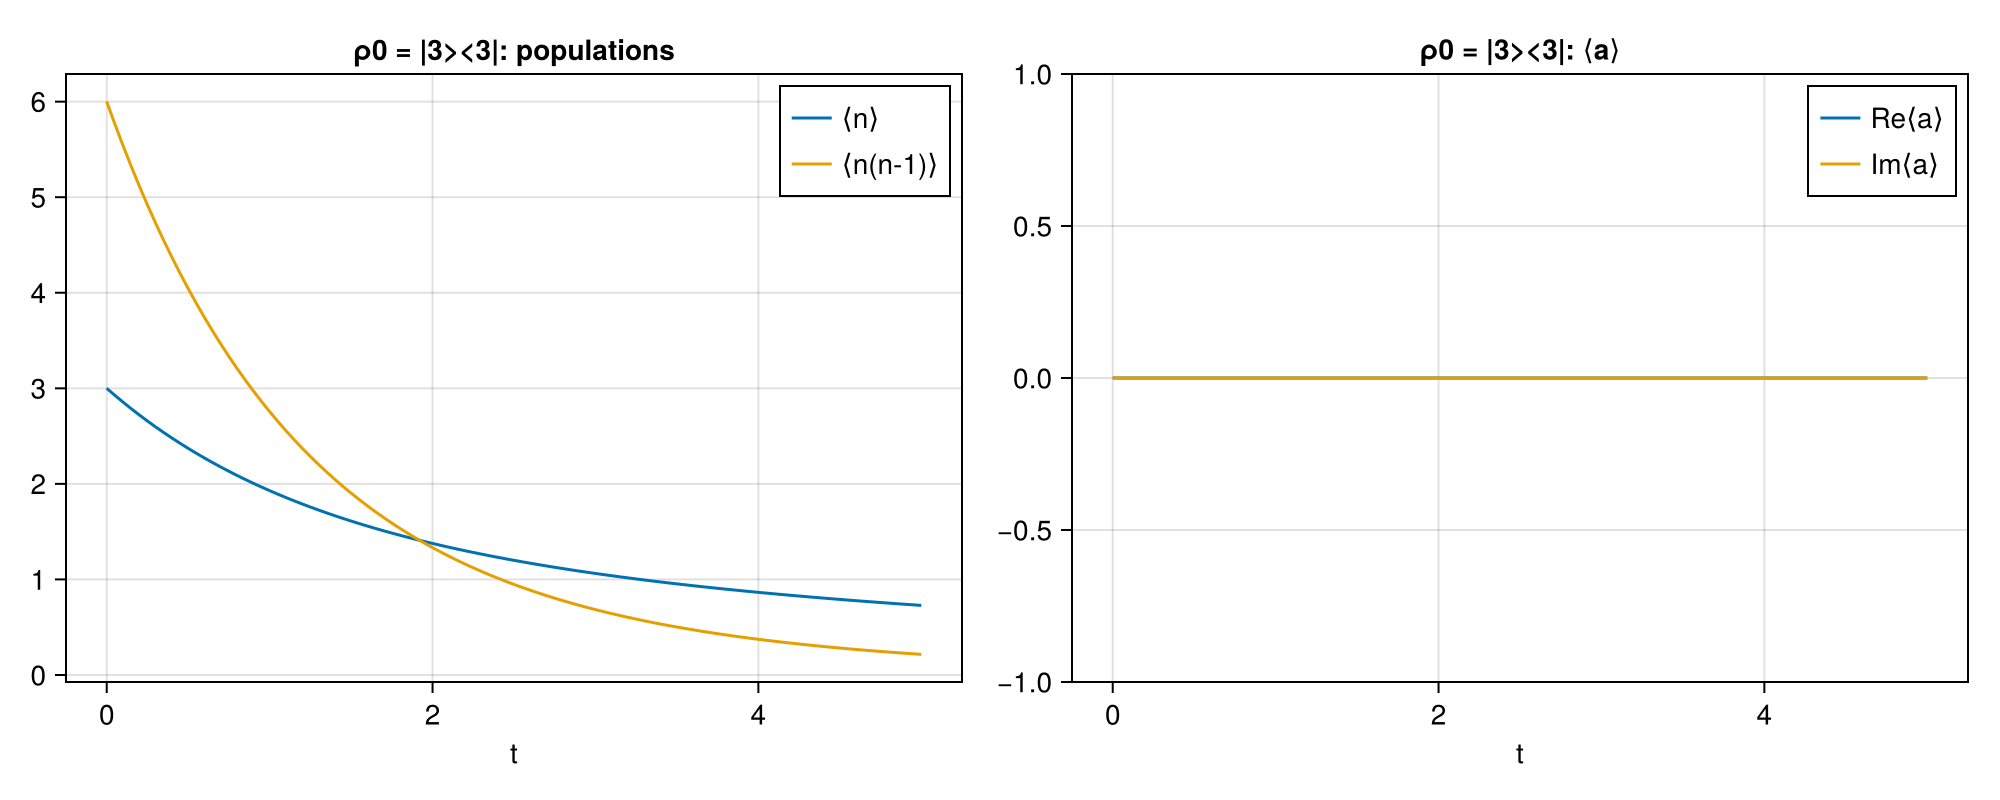

CairoMakie.Screen{PDF}


In [30]:
s0 = s_enr_space((cutoff,), 0, 2)
#s = s_enrspace((cutoff,), 1, 2)
a_left, a_right = s_enr_destroy(s0, 1)
vec_id = s_enr_identity(s0) 
H_left = ω * a_left' * a_left + (U/2) * a_left'^2 * a_left^2
H_right = ω * a_right' * a_right + (U/2) * a_right'^2 * a_right^2
c_ops = [(sqrt(γ)*a_left, sqrt(γ)*a_right), (sqrt(γ)*a_left^2, sqrt(γ)*a_right^2)]

L_restricted = s_enr_liouvillian(s0, H_left, H_right, c_ops)
ρ_r = s_enr_projector(s0, 3, 3)


# === Observables (left-acting, projected to target) ===
N_left  = a_left' * a_left            # number
N2_left = a_left'^2 * a_left^2        # pairs
A_left  = a_left                      # for ⟨a⟩

# project to target
N_target  = project_to_target(N_left,  s0)
N2_target = project_to_target(N2_left, s0)
A_target  = project_to_target(A_left,  s0)

observables = [N_target, N2_target, A_target]
results = s_enr_mesolve(L_restricted, ρ_r, tlist, vec_id; observables, method=:eigen)
evolution = results.states
tracepreservation = [vec_id' * state for state in evolution]
nonzero_values = filter(x -> abs(x-1.) > 1e-9, tracepreservation)
println("Trace preservation check (<I|ρ(t)> - 1 = 0): ", nonzero_values)
N_t  = real.(results.expect[1, :])
N2_t = real.(results.expect[2, :])
A_t  = results.expect[3, :]   # complex

# === Plot ===
fig = Figure(size = (1000, 400))
ax1 = Axis(fig[1,1], title="ρ0 = |3><3|: populations", xlabel="t")
lines!(ax1, tlist, N_t,  label="⟨n⟩")
lines!(ax1, tlist, N2_t, label="⟨n(n-1)⟩")
axislegend(ax1)

ax2 = Axis(fig[1,2], title="ρ0 = |3><3|: ⟨a⟩", xlabel="t")
lines!(ax2, tlist, real.(A_t), label="Re⟨a⟩")
lines!(ax2, tlist, imag.(A_t), label="Im⟨a⟩")
axislegend(ax2)
display(fig)
save("dynamics1.pdf", fig)


Trace preservation check (<I|ρ(t)> - 1 = 0): ComplexF64[]


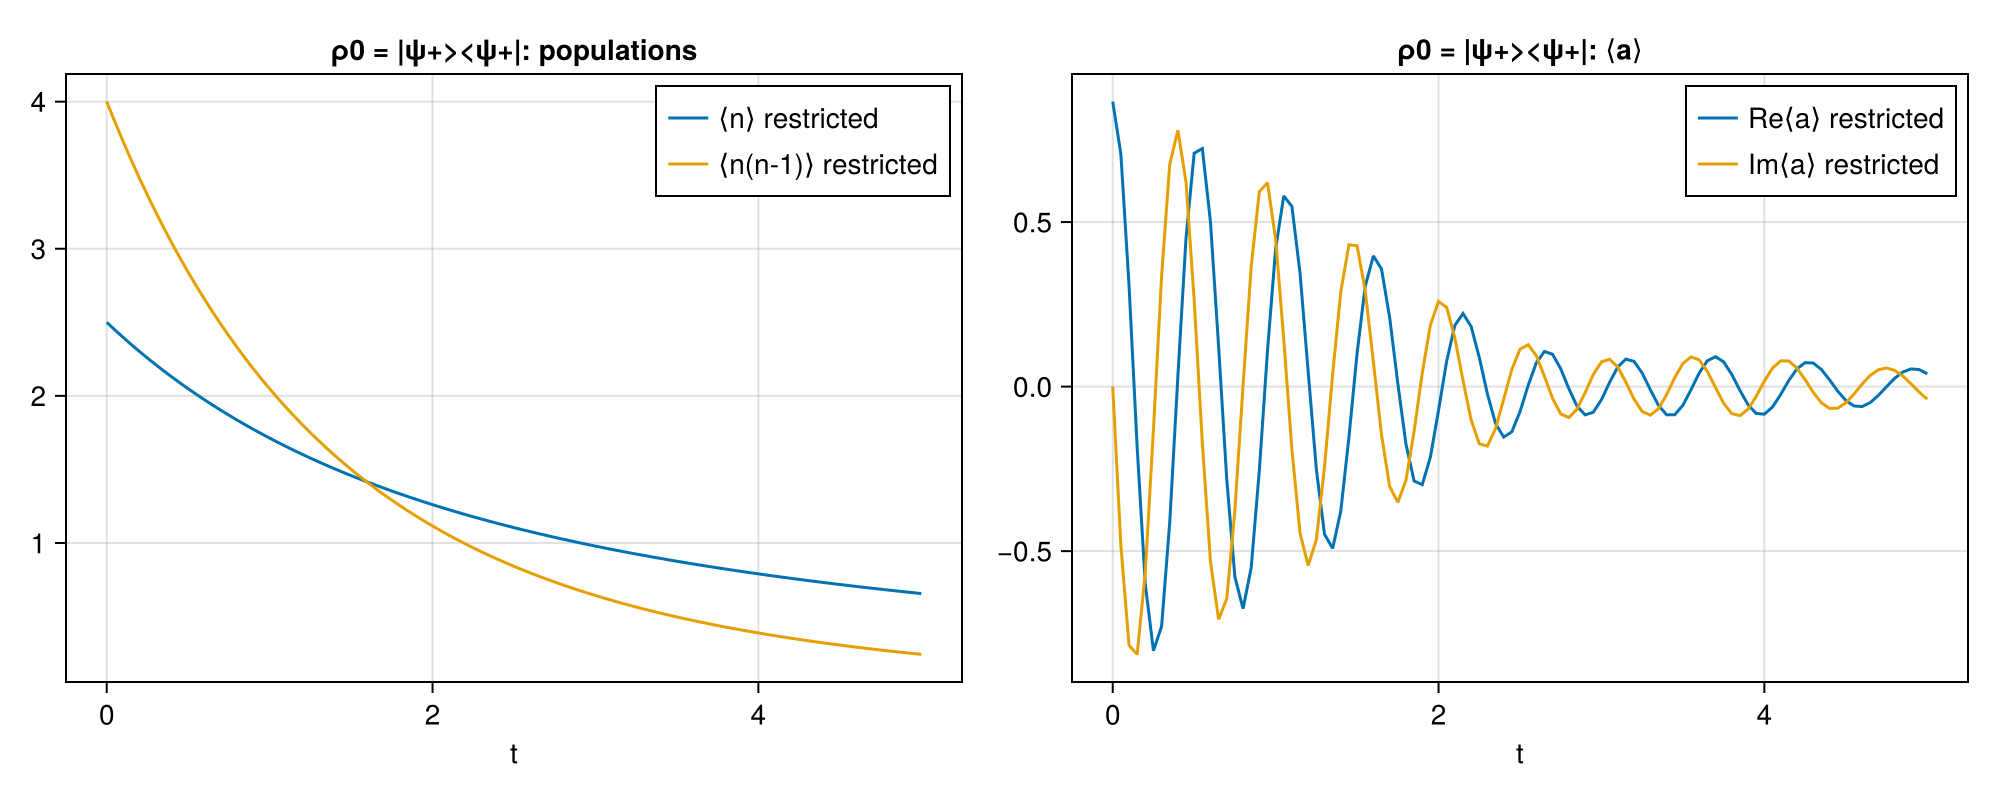

CairoMakie.Screen{PDF}


In [29]:
# ρ₀ = ½(|2⟩⟨2| + |2⟩⟨3| + |3⟩⟨2| + |3⟩⟨3|)
space = s_enr_space((cutoff,), 1, 2)

a_left, a_right = s_enr_destroy(space, 1)
vec_id = s_enr_identity(space) 
H_left = ω * a_left' * a_left + (U/2) * a_left'^2 * a_left^2
H_right = ω * a_right' * a_right + (U/2) * a_right'^2 * a_right^2
c_ops = [(sqrt(γ)*a_left, sqrt(γ)*a_right), (sqrt(γ)*a_left^2, sqrt(γ)*a_right^2)]

L_restricted = s_enr_liouvillian(space, H_left, H_right, c_ops)

ρ0_state2 = 0.5 * (s_enr_projector(space, [2], [2]) +
                   s_enr_projector(space, [2], [3]) +
                   s_enr_projector(space, [3], [2]) +
                   s_enr_projector(space, [3], [3]))


# observables
N_left  = a_left' * a_left            # number
N2_left = a_left'^2 * a_left^2        # pairs
A_left  = a_left                      # for ⟨a⟩

# project to target
N_target  = project_to_target(N_left,  space)
N2_target = project_to_target(N2_left, space)
A_target  = project_to_target(A_left,  space)

observables = [N_target, N2_target, A_target]

# evolve and compute observables
results_state2 = s_enr_mesolve(L_restricted, ρ0_state2, tlist, vec_id; observables, method=:eigen)

evolution_state2 = results_state2.states  
tracepreservation = [vec_id' * state for state in evolution_state2]
nonzero_values = filter(x -> abs(x-1.) > 1e-9, tracepreservation)
println("Trace preservation check (<I|ρ(t)> - 1 = 0): ", nonzero_values)
N_t_s2  = real.(results_state2.expect[1, :])
N2_t_s2 = real.(results_state2.expect[2, :])
A_t_s2  = results_state2.expect[3, :]   # complex — keep both parts


fig = Figure(size = (1000, 400))
ax1 = Axis(fig[1,1], title="ρ0 = |ψ+><ψ+|: populations", xlabel="t")
lines!(ax1, tlist, N_t_s2, label="⟨n⟩ restricted")
lines!(ax1, tlist, N2_t_s2, label="⟨n(n-1)⟩ restricted")
axislegend(ax1)

ax2 = Axis(fig[1,2], title="ρ0 = |ψ+><ψ+|: ⟨a⟩", xlabel="t")
lines!(ax2, tlist, real.(A_t_s2), label="Re⟨a⟩ restricted")
lines!(ax2, tlist, imag.(A_t_s2), label="Im⟨a⟩ restricted")
axislegend(ax2)
display(fig)
save("dynamics2.pdf", fig)